In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("cleaned_fw_dataset.csv")
df.head()

,Product_Name,Category,Date_Received,Expiration_Date,Stock_Quantity,Unit_Price,Sales_Volume,Inventory_Turnover_Rate,Shelf_Life,Food_Waste_kg
0,Bell Pepper,Fruits & Vegetables,2024-03-01,2025-01-31,46,4.6,96,55,336.0,0.00000
1,Vegetable Oil,Oils & Fats,2024-04-01,2024-06-11,51,2.0,24,83,71.0,0.37500
2,Parmesan Cheese,Dairy,2024-04-01,2024-04-08,38,12.0,35,24,7.0,0.37500
3,Carrot,Fruits & Vegetables,2024-05-01,2024-09-26,51,1.5,44,95,148.0,0.04698
4,Garlic,Fruits & Vegetables,2024-05-01,2024-05-20,27,7.0,91,77,19.0,0.00000


In [3]:
df['Date_Received'] = pd.to_datetime(df['Date_Received'])
df['Expiration_Date'] = pd.to_datetime(df['Expiration_Date'])

df['days_to_expire'] = (df['Expiration_Date'] - df['Date_Received']).dt.days

In [4]:
df = df.drop(['Product_Name','Date_Received','Expiration_Date'], axis=1)

In [5]:
X = df.drop("Food_Waste_kg", axis=1)
y = df["Food_Waste_kg"]

In [6]:
categorical_cols = ['Category']
numeric_cols = X.select_dtypes(include=np.number).columns

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', LabelEncoder(), 'Category'),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

In [8]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

dt.fit(X_train_proc, y_train)

preds = dt.predict(X_test_proc)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("Decision Tree Results")
print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Decision Tree Results
R2: 0.9516206284608347
MAE: 1.3771434133985028
RMSE: 3.4483834740551305


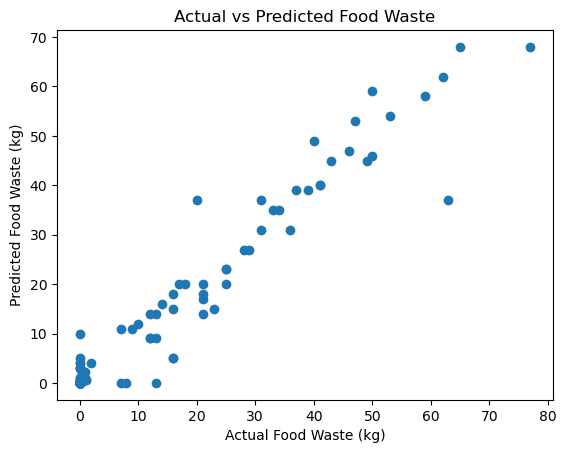

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Food Waste (kg)")
plt.ylabel("Predicted Food Waste (kg)")
plt.title("Actual vs Predicted Food Waste")
plt.show()

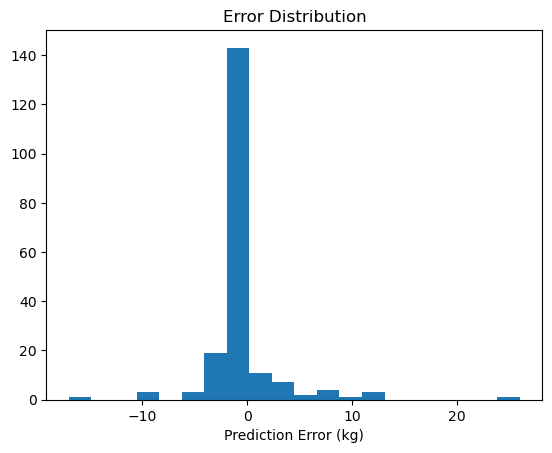

In [14]:
errors = y_test - preds

plt.hist(errors, bins=20)
plt.xlabel("Prediction Error (kg)")
plt.title("Error Distribution")
plt.show()